# 1. Data Profiling

## Load Insurance Fraud data

In [ ]:
# import pandas library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load data from Google drive
# df = pd.read_csv('insurance_fraud.csv')
df = pd.read_csv('/content/drive/My Drive/WIDS/insurance_fraud.csv')

# Display the first 5 rows of the data
df.head()

,Month,Make,AccidentArea,MonthClaimed,Sex,MaritalStatus,Fault,VehicleCategory,VehiclePrice,Deductible,...,PoliceReportFiled,WitnessPresent,AgentType,AddressChange_Claim,NumberOfCars,BasePolicy,FraudFound_P,PolicyNumber,Year,RegistrationDate
0,Jul,Honda,Urban,Sep,Male,Single,Policy Holder,Sedan,96494,400.0,...,No,No,External,no change,1 vehicle,All Perils,1.0,509343533,2023,2023-01-05 00:01:01.000001
1,Jul,Honda,Rural,Jan,Male,Married,Policy Holder,Sport,89807,400.0,...,No,No,External,no change,1 vehicle,Collision,1.0,600000326,2023,2020-11-09 00:01:01.000001
2,Jul,Honda,Urban,Aug,Male,Married,Policy Holder,Sedan,25517,400.0,...,No,No,External,no change,1 vehicle,Collision,1.0,935545676,2023,2016-02-24 00:01:01.000001
3,Nov,Honda,Urban,Jan,Male,Single,Policy Holder,Sport,70903,400.0,...,No,No,External,no change,1 vehicle,Collision,1.0,620550528,2023,2017-04-30 00:01:01.000001
4,Nov,Toyota,Urban,Jan,Male,Married,Policy Holder,Sedan,28016,400.0,...,No,No,External,no change,1 vehicle,Collision,1.0,795966429,2023,2017-05-21 00:01:01.000001


### Data Dictionary
| Accenture Data and AI   | Variable Name        | Format   | Possible_Values                                                                                                 | Description                                                                             |
|:------------------------|:---------------------|:-------------|:----------------------------------------------------------------------------------------------------------------|:--------------------------------------------------------------------------------------|
| 1                       | Month                | Character    | Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, Oct, Nov, Dec                                                      | The month the accident happened                                                       |
| 2                       | Make                 | Character    | Honda, Toyota, Chevrolet, Accura, Mazda, Pontiac, BMW, Dodge, Ford, Mercedes, Mercury, Nissan, Saab, Saturn, VW | The make of the vehicle the claim was for                                             |
| 3                       | AccidentArea         | Character    | Urban, Rural                                                                                                    | The type of geographical area the accident happened in                                |
| 4                       | MonthClaimed         | Character    | Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, Oct, Nov, Dec                                                      | The month the claim was made in                                                       |
| 5                       | Sex                  | Character    | Male, Female                                                                                                    | The sex of the person who made the claim                                              |
| 6                       | MaritalStatus        | Character    | Married, Widow, Divorced, Single                                                                                | The marital status of the person who made the claim                                   |
| 7                       | Fault                | Character    | Policy Holder, Third Party                                                                                      | The person who is at fault in the claim                                               |
| 8                       | VehicleCategory      | Character    | Sedan, Sport, Utility                                                                                           | The category of the vehicle the claim was made for                                    |
| 9                       | VehiclePrice         | Numeric      | 100 to 100000                                                                                                   | The price of the vehicle the claim was made for                                       |
| 10                      | Deductible           | Numeric      | 300, 400,500,700                                                                                                | The value of the deductible on the policy                                             |
| 11                      | DriverRating         | Numeric      | 1 to 4                                                                                                          | The rating of the driver based off previous policies                                  |
| 12                      | Days_Policy_Accident | Character    | none, 1 to 7, 8 to 15, 15 to 30, more than 30                                                                   | The number of days the policy has been active before the accident                     |
| 13                      | Days_Policy_Claim    | Character    | none,  8 to 15, 15 to 30, more than 30                                                                          | The number of days the policy has been active before the claim                        |
| 14                      | PastNumberOfClaims   | Character    | none, 1, 2 to 4, more than 4                                                                                    | The past number of claims of the owner of the policy                                  |
| 15                      | AgeOfPolicyHolder    | Character    | 25 and under, over 25                                                                                           | The age of the policy holder in bins                                                  |
| 16                      | PoliceReportFiled    | Character    | Yes, No                                                                                                         | Field if the accident was reported to the police                                      |
| 17                      | WitnessPresent       | Character    | Yes, No                                                                                                         | Field if there was a witness present for the accident                                 |
| 18                      | AgentType            | Character    | External, Internal                                                                                              | The type of insurance agent for the claim                                             |
| 19                      | AddressChange_Claim  | Character    | under 6 months, 1 year, 2 to 3 years, 4 to 8 years, no change                                                   | The time since the last change of address for policy holder at time of claim          |
| 20                      | NumberOfCars         | Character    | 1 vehicle, 2 vehicles, 3 to 4, 5 to 8                                                                           | The number of cars involved in the accident being claimed on                          |
| 21                      | BasePolicy           | Character    | All Perils, Collision, Liability                                                                                | The Base Insurance Policy type                                                        |
| 22                      | FraudFound_P         | Numeric      | 0 , 1                                                                                                           | Binary if the claim was fraudulent (1 indicates fraud was found in the investigation) |
| 23                      | RegistrationDate     | DateTime     | Any DateTime in form DD/MM/YY HH:MM:SS                                                                          | The date and time of registration of the vehicle                                      |
| 24                      | Year                 | Numeric      | 2023                                                                                                            | Year that claim was made                                                              |
| 25                      | PolicyNumber         | Numeric      | Any number                                                                                                      | ID of the insurance policy associated with the case                                   |

## Remove Duplicate Rows

In [ ]:
# @title Default title text
lenBefore = len(df)

# Drop duplicates
df = df.drop_duplicates()

lenAfter = len(df)

print("We have removed " + str(lenBefore-lenAfter) + " duplicates.")
print("Now, we have " + str(lenAfter) + " rows.")



We have removed 41 duplicates.
Now, we have 20295 rows.


## Data Exploration

In [ ]:
# List the unique value for each column
for column in df.columns:
    unique_values = df[column].unique()
    print(f"'{column}' -  {unique_values}")

'Month' -  ['Jul' 'Nov' 'Dec' 'Jan' 'Aug' 'Feb' 'Mar' 'Jun' 'Apr' 'May' 'Oct' 'Sep']
'Make' -  ['Honda' 'Toyota' 'Chevrolet' 'Accura' 'Mazda' 'Pontiac' 'Ford' nan 'VW'
 'Dodge' 'Saab' 'Nissan' 'Saturn' 'Mercury' 'Mercedes' 'BMW' 'Jaguar'
 'Porsche' 'Ferrari' 'Lexus']
'AccidentArea' -  ['Urban' 'Rural']
'MonthClaimed' -  ['Sep' 'Jan' 'Aug' 'Dec' 'May' 'Nov' 'Feb' 'Apr' 'Mar' 'Oct' 'Jul' 'Jun']
'Sex' -  ['Male' 'MALE' 'Female' nan 'FEMALE']
'MaritalStatus' -  ['Single' 'Married' 'Divorced' 'Widow']
'Fault' -  ['Policy Holder' 'Third Party']
'VehicleCategory' -  ['Sedan' 'Sport' 'Utility']
'VehiclePrice' -  [96494 89807 25517 ... 37556 34145 14796]
'Deductible' -  [400. 500. 700. 300.  nan 379. 391. 354. 321. 380. 310. 333. 311. 320.
 322. 324. 377. 355.]
'DriverRating' -  [ 1.  4. -2.  3.  2. nan]
'Days_Policy_Accident' -  ['more than 30' 'none' '1 to 7' '8 to 15' '15 to 30']
'Days_Policy_Claim' -  ['more than 30' '8 to 15' '15 to 30' 'none']
'PastNumberOfClaims' -  ['none' '1' 'more tha

In [ ]:
# Count the NaN value for each column
nan_counts = df.isnull().sum()
print(nan_counts)

Month                     0
Make                     97
AccidentArea              0
MonthClaimed              0
Sex                      95
MaritalStatus             0
Fault                     0
VehicleCategory           0
VehiclePrice              0
Deductible              111
DriverRating            107
Days_Policy_Accident      0
Days_Policy_Claim         0
PastNumberOfClaims        0
AgeOfPolicyHolder         0
PoliceReportFiled       101
WitnessPresent          106
AgentType                 0
AddressChange_Claim       0
NumberOfCars              0
BasePolicy                0
FraudFound_P             88
PolicyNumber              0
Year                      0
RegistrationDate          0
dtype: int64


In [ ]:
# Get summary stats of the table
df.describe()

,VehiclePrice,Deductible,DriverRating,FraudFound_P,PolicyNumber,Year
count,20295.000000,20184.000000,20188.000000,20207.000000,2.029500e+04,20295.0
mean,35228.366396,408.475872,2.447246,0.285891,5.488499e+08,2023.0
std,22521.095503,44.662922,1.112995,0.451849,2.599951e+08,0.0
min,7.000000,300.000000,-2.000000,0.000000,1.000077e+08,2023.0
25%,22949.000000,400.000000,1.000000,0.000000,3.237075e+08,2023.0
50%,27228.000000,400.000000,2.000000,0.000000,5.474066e+08,2023.0
75%,35887.500000,400.000000,3.000000,1.000000,7.760160e+08,2023.0
max,414638.000000,700.000000,4.000000,1.000000,9.999889e+08,2023.0


In [ ]:
df['Sex'].value_counts().sort_index()

FEMALE       62
Female     5390
MALE        139
Male      14609
Name: Sex, dtype: int64

In [ ]:
df['Make'].value_counts().sort_index()

Accura        757
BMW            18
Chevrolet    2066
Dodge         109
Ferrari         2
Ford          493
Honda        3763
Jaguar          6
Lexus           1
Mazda        2893
Mercedes        4
Mercury        85
Nissan         30
Pontiac      5233
Porsche         5
Saab          115
Saturn         60
Toyota       4270
VW            288
Name: Make, dtype: int64

### Data Format Standardization according to the data dictionary

1. "Make" column: Distribute each existing unique value evenly among these NaN values

In [ ]:
def fill_na_with_distribution(df, column_name):
    unique_values = df[column_name].dropna().unique() # Find unique values
    nan_count = df[column_name].isna().sum() # Count nan value
    values_per_unique_value = nan_count // len(unique_values) # Determine how many NaNs each unique value should be assigned to, ensuring as even a distribution as possible.

    # Assign values
    replacement_values = []
    for value in unique_values:
        replacement_values.extend([value] * values_per_unique_value)

    # Handle the remaining NaNs if they can't be evenly distributed
    remainder = nan_count % len(unique_values)
    if remainder > 0:
        additional_values = np.random.choice(unique_values, size=remainder, replace=False)
        replacement_values.extend(additional_values)

    # Replace NaNs
    nan_indices = df[column_name][df[column_name].isna()].index[:len(replacement_values)]
    df.loc[nan_indices, column_name] = replacement_values

fill_na_with_distribution(df, 'Make')

2. "Sex" column: standardize the value to "Female" and "Male", fill in the Nan value

In [ ]:
# Convert 'MALE' to 'Male' and 'FEMALE' to 'Female'
df['Sex'] = df['Sex'].str.capitalize()

# Replace NaN values with 'Female'
df.fillna({'Sex':'Female'}, inplace=True)

df['Sex'].value_counts().sort_index()

Female     5547
Male      14748
Name: Sex, dtype: int64

3. "Deductible" column: replace the Nan value with the mean value of deductible

In [ ]:
df.fillna({'Deductible':408}, inplace=True)

4. “DriverRating” column: replace the Nan value with the mean value of Drive rating and replace -2 to 2

In [ ]:
df['DriverRating'] = pd.to_numeric(df['DriverRating'])
df.fillna({'DriverRating':2.0}, inplace=True)
df['DriverRating'] = df['DriverRating'].replace(-2, 2)
df['DriverRating'].dtype

dtype('float64')

5. "PoliceReportFiled" column: Distribute each existing unique value evenly among these NaN values

In [ ]:
fill_na_with_distribution(df, 'PoliceReportFiled')

6. "WitnessPresent" column: Distribute each existing unique value evenly among these NaN values

In [ ]:
fill_na_with_distribution(df, 'WitnessPresent')

7.“FraudFound_P": Replace Nan to 1 (To be decided)

In [ ]:
df.fillna({'FraudFound_P':1.0}, inplace=True)

8. RegistrationDate: Transfer the format to DD/MM/YY

In [ ]:
df['RegistrationDate'] = pd.to_datetime(df['RegistrationDate'])

# 格式化日期为 DD/MM/YY
df['RegistrationDate'] = df['RegistrationDate'].dt.strftime('%d/%m/%y')

## Outliers

<Axes: >

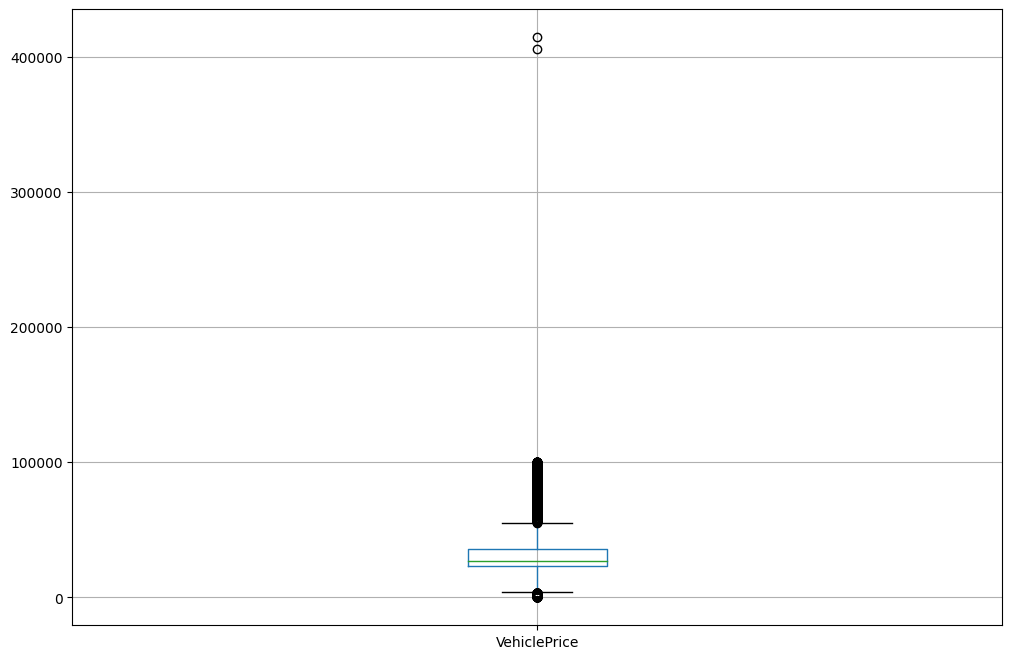

In [ ]:
df[['VehiclePrice']].boxplot(figsize=(12, 8))


In [ ]:
# calculate mean value below 400000
mean_value = int(round(df.loc[df['VehiclePrice'] <= 400000, 'VehiclePrice'].mean()))

# replace over 400000
df.loc[df['VehiclePrice'] > 400000, 'VehiclePrice'] = mean_value

## New dataset

In [ ]:
# Count the NaN value for each column
nan_counts = df.isnull().sum()
print(nan_counts)

Month                   0
Make                    0
AccidentArea            0
MonthClaimed            0
Sex                     0
MaritalStatus           0
Fault                   0
VehicleCategory         0
VehiclePrice            0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
AddressChange_Claim     0
NumberOfCars            0
BasePolicy              0
FraudFound_P            0
PolicyNumber            0
Year                    0
RegistrationDate        0
dtype: int64


## Data visualization

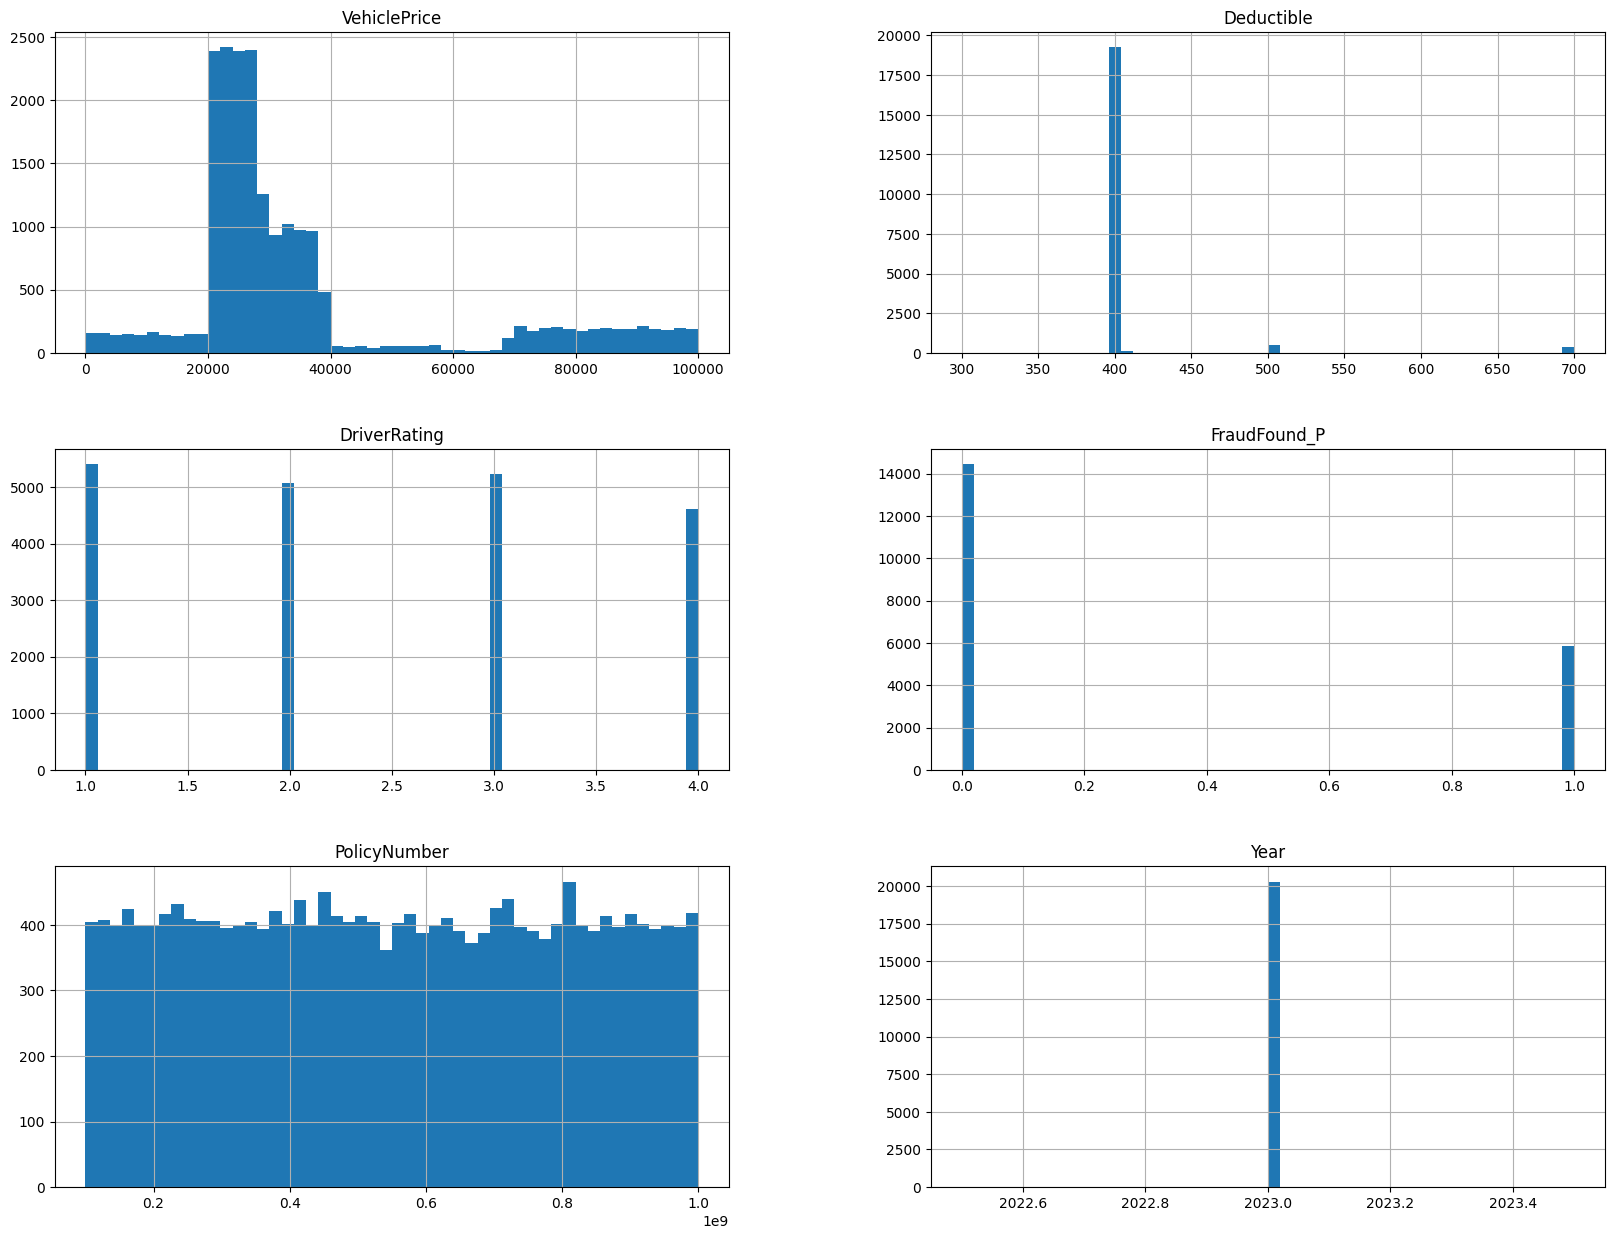

In [ ]:
# Visual inspection of the numeric data using Histograms
%matplotlib inline

# matplotlib is traditionally loaded as "plt"
import matplotlib.pyplot as plt
df.hist(bins=50, figsize=(20,15))
plt.show()

In [ ]:
corr_matrix = df.corr(numeric_only = True)
corr_matrix

,VehiclePrice,Deductible,DriverRating,FraudFound_P,PolicyNumber,Year
VehiclePrice,1.000000,-0.020713,-0.013841,0.015965,0.005200,NaN
Deductible,-0.020713,1.000000,-0.000321,0.033712,0.006439,NaN
DriverRating,-0.013841,-0.000321,1.000000,-0.052136,-0.001120,NaN
FraudFound_P,0.015965,0.033712,-0.052136,1.000000,0.001383,NaN
PolicyNumber,0.005200,0.006439,-0.001120,0.001383,1.000000,NaN
Year,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
corr_matrix["FraudFound_P"].sort_values(ascending = False)

FraudFound_P    1.000000
Deductible      0.033712
VehiclePrice    0.015965
PolicyNumber    0.001383
DriverRating   -0.052136
Year                 NaN
Name: FraudFound_P, dtype: float64

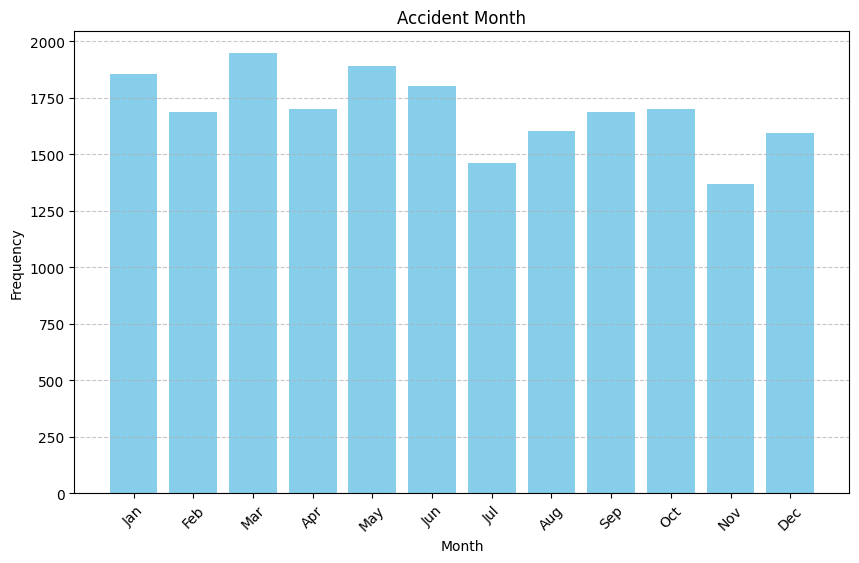

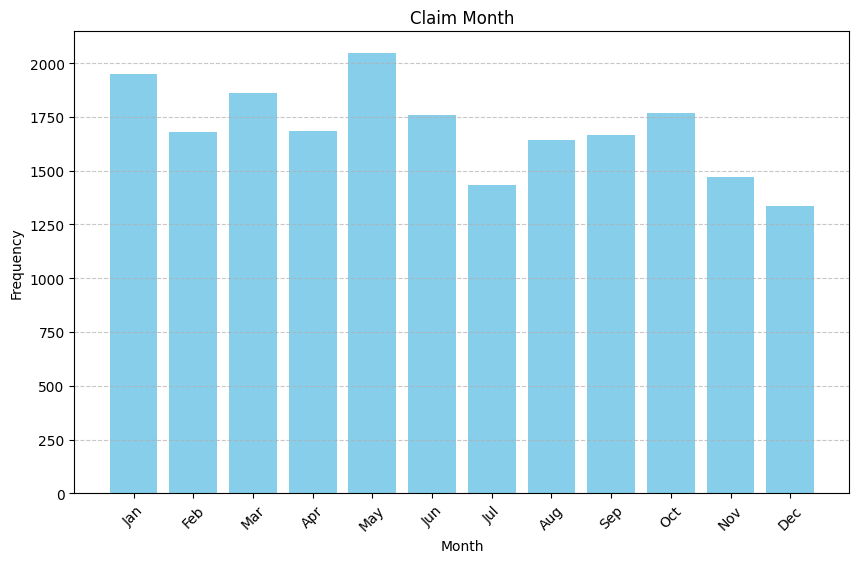

In [ ]:
def plot_distribution(df, column_name,plot_name,Xlabel):

    distribution = df[column_name].value_counts().reindex(
        ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    )

    # 绘制树状图
    plt.figure(figsize=(10, 6))
    plt.bar(distribution.index, distribution.values, color='skyblue')
    plt.title(plot_name)
    plt.xlabel(Xlabel)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

plot_distribution(df, 'Month','Accident Month','Month')
plot_distribution(df, 'MonthClaimed','Claim Month','Month')


In [ ]:
# def plot_category_distribution(df, column_name):
#     category_distribution = df[column_name].value_counts().sort_values(ascending=False)
#     plt.figure(figsize=(12, 8))
#     sns.barplot(x=category_distribution.values, y=category_distribution.index, palette='viridis')
#     plt.title(f'{column_name} Distribution')
#     plt.xlabel('Frequency')
#     plt.ylabel(column_name)
#     plt.show()

# plot_category_distribution(df, 'Make')

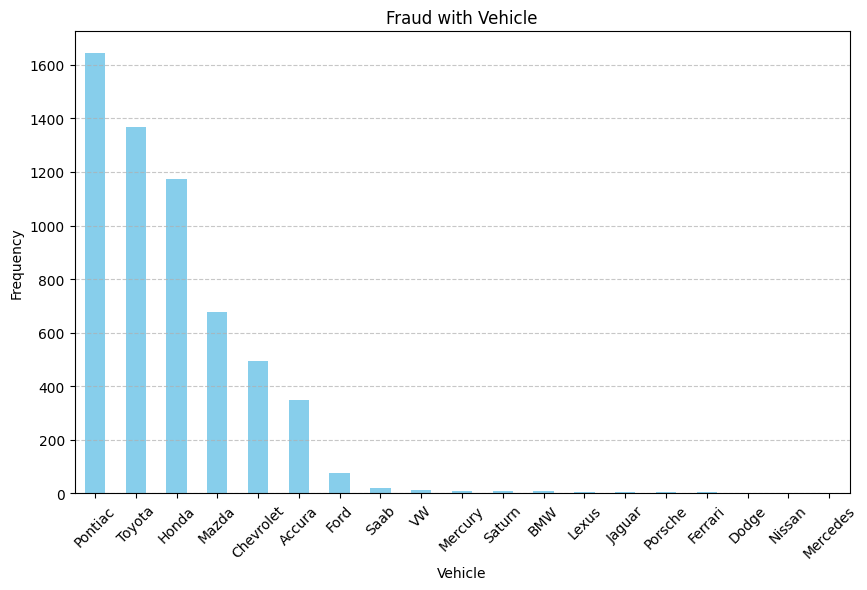

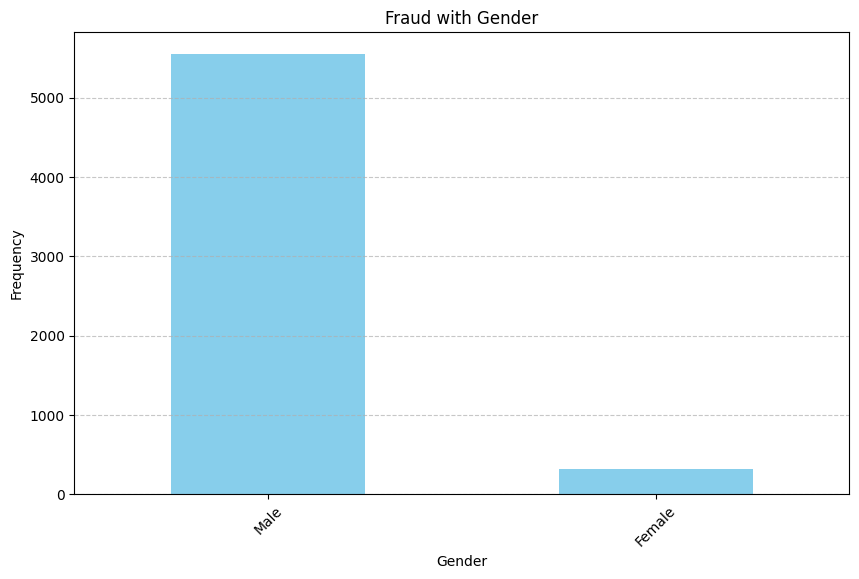

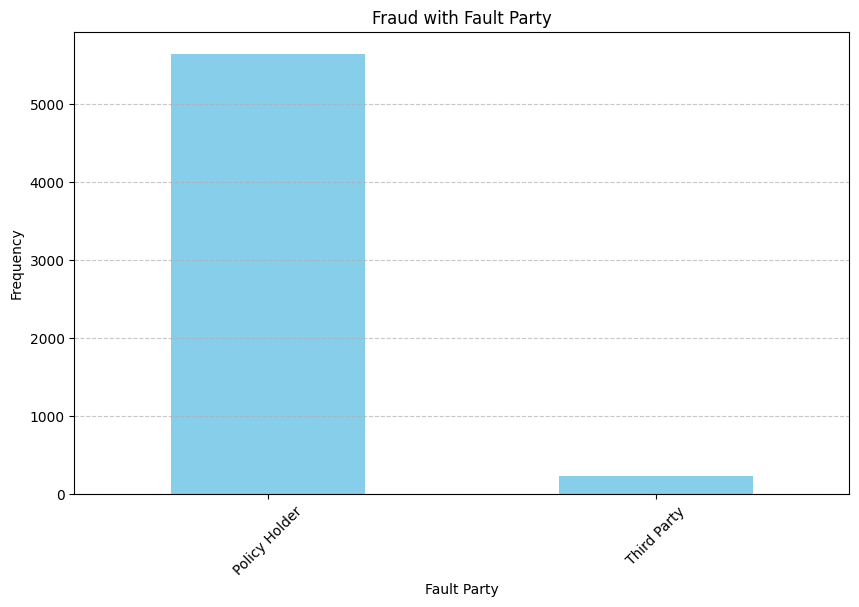

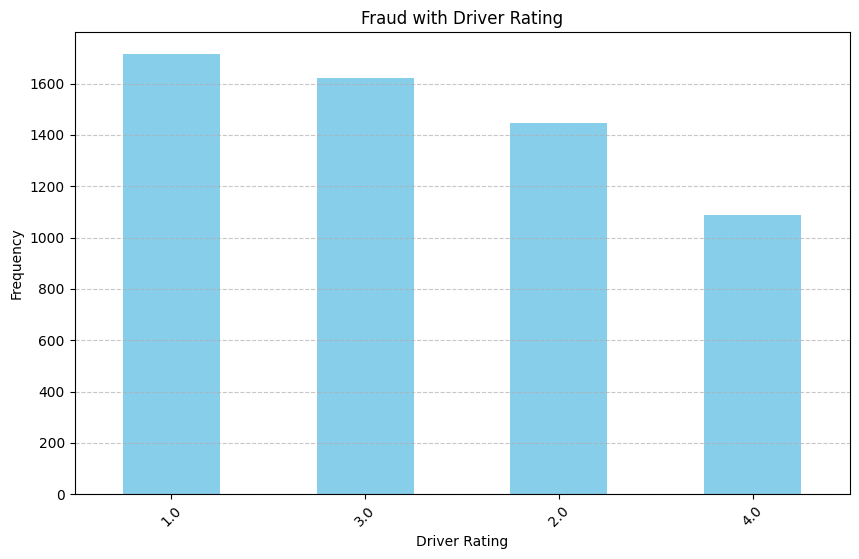

In [ ]:
def plot_relation_fraud(df,fraud_column,cause_column,Title):
    fraud_df = df[df[fraud_column] == 1][cause_column].value_counts()

    plt.figure(figsize=(10, 6))
    fraud_df.plot(kind='bar', color='skyblue')
    plt.title('Fraud with ' + Title )
    plt.xlabel(Title)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

plot_relation_fraud(df,'FraudFound_P','Make','Vehicle')
plot_relation_fraud(df,'FraudFound_P','Sex','Gender')
plot_relation_fraud(df,'FraudFound_P','Fault','Fault Party')
plot_relation_fraud(df,'FraudFound_P','DriverRating','Driver Rating')

In [ ]:
!pip install ydata-profiling

In [ ]:
from ydata_profiling import ProfileReport

# Profile the data
profile = ProfileReport(df, title="Profiling Report")

In [ ]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]